In [ ]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy.sparse as sp

matplotlib.rcParams['pdf.fonttype'] = 42

color_palette = {}
color_palette['wt'] = 'blue'
color_palette['mutated'] = 'red'
color_palette['heterozygous'] = 'orange'

import scipy.stats as st

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


In [ ]:
adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/Integrated_MPN_scvi_genotyped_nb.h5ad')
adata = adata[adata.obs['cell_type'] != 'Monocyte/Platelet doublet (non-HSPC)']

/tmp/ipykernel_779653/2927516652.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['JAK2_WTA_count'] = pd.Series(col.toarray().ravel(), index=adata.obs_names, name=gene)
/tmp/ipykernel_779653/2927516652.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showfliers=False, widths=0.8)


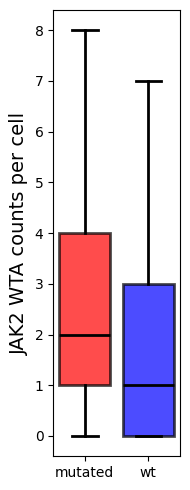

In [3]:
gene = 'JAK2'
col = adata.layers['raw_data'][:, adata.var_names.get_loc(gene)]
adata.obs['JAK2_WTA_count'] = pd.Series(col.toarray().ravel(), index=adata.obs_names, name=gene)

variant = 'JAK2 c.1849G>T'

fig,ax = plt.subplots(figsize=(2,5))

data_to_plot = []
labels = []

for genotype in ['mutated','wt']:
    genotype_data = adata[adata.obs['genotype'] == f'{variant}_{genotype}'].obs['JAK2_WTA_count']
    data_to_plot.append(genotype_data)
    labels.append(genotype)

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, showfliers=False, widths=0.8)

# Color the boxplots
for patch, genotype in zip(bp['boxes'], labels):
    patch.set_facecolor(color_palette[genotype])
    patch.set_linewidth(2)
    patch.set_alpha(0.7)
# Style the other boxplot elements
for whisker in bp['whiskers']:
    whisker.set_linewidth(2)
for cap in bp['caps']:
    cap.set_linewidth(2)
for median_line in bp['medians']:
    median_line.set_color('black')
    median_line.set_linewidth(2)

ax.set_ylabel('JAK2 WTA counts per cell', fontsize=14)

plt.tight_layout()
# plt.savefig('../plots/JAK2_WTA_counts_by_genotype.pdf')

In [4]:
st.mannwhitneyu(data_to_plot[0], data_to_plot[1], alternative='greater')

MannwhitneyuResult(statistic=7633153422.5, pvalue=0.0)

In [5]:
print(len(data_to_plot[0]), 'mutated cells')
print(len(data_to_plot[1]), 'wt cells')

138090 mutated cells
97513 wt cells
